# Analíticas de Idealista Scraper
Este notebook te permite analizar los resultados guardados en los archivos CSV.
Ejecuta las celdas paso a paso. Los gráficos se mostrarán aquí y también se guardarán en una carpeta con el mismo nombre del CSV.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import webbrowser
import time
#  ESCANEAR ARCHIVOS CSV EN LA CARPETA DATA
data_dir = "../output"
all_files = []
if os.path.exists(data_dir):
    for root_dir, dirs, files in os.walk(data_dir):
        for file in files:
            if file.endswith(".csv"):
                all_files.append(os.path.join(root_dir, file))
# Crear listas dinámicas de archivos de Rent y Buy
rent_files = sorted([f for f in all_files if "_rent_" in f.lower() or "\\rent_" in f.lower() or "/rent_" in f.lower()])
buy_files = sorted([f for f in all_files if "_buy_" in f.lower() or "\\buy_" in f.lower() or "/buy_" in f.lower()])
rent_txt = "\n".join([f"  [{i}] {os.path.relpath(f, data_dir)}" for i, f in enumerate(rent_files)])
buy_txt = "\n".join([f"  [{i}] {os.path.relpath(f, data_dir)}" for i, f in enumerate(buy_files)])
print(f"--- ARCHIVOS DE ALQUILER (Rent) ENCONTRADOS ---\nTotal: {len(rent_files)}\n{rent_txt}")
print(f"\n--- ARCHIVOS DE COMPRA (Buy) ENCONTRADOS ---\nTotal: {len(buy_files)}\n{buy_txt}")

--- ARCHIVOS DE ALQUILER (Rent) ENCONTRADOS ---
Total: 0


--- ARCHIVOS DE COMPRA (Buy) ENCONTRADOS ---
Total: 21
  [0] 100000-200000_buy_new_Costa_Val\Costa_Val.csv
  [1] 100000-220000_buy_used_Ali_afueras\Ali_afueras.csv
  [2] 100000-240000_buy_used_Bcn_afueras\Bcn_afueras.csv
  [3] 100000-260000_buy_used_Bcn_dentro\Bcn_dentro.csv
  [4] 110000-170000_buy_used_Ali_dentro\Ali_dentro.csv
  [5] 110000-190000_buy_used_Sev_fuera\Sev_fuera.csv
  [6] 110000-230000_buy_used_Sev_dentro\Sev_dentro.csv
  [7] 110000-270000_buy_used_Mal_dentro\Mal_dentro.csv
  [8] 110000-280000_buy_used_Mal_afueras\Mal_afueras.csv
  [9] 110000-320000_buy_new_Alic_afueras\Alic_afueras.csv
  [10] 110000-320000_buy_new_Alic_dentro\Alic_dentro.csv
  [11] 110000-320000_buy_new_Bcn_afueras\Bcn_afueras.csv
  [12] 110000-320000_buy_new_Bcn_dentro\Bcn_dentro.csv
  [13] 110000-320000_buy_new_Mal_afueras\Mal_afueras.csv
  [14] 110000-320000_buy_new_Mal_dentro\Mal_dentro.csv
  [15] 110000-320000_buy_new_Sev_afueras\Sev_afuera

In [2]:
CSV_FILENAME = buy_files[0]
base_name = os.path.splitext(os.path.basename(CSV_FILENAME))[0]
OUTPUT_DIR = os.path.dirname(CSV_FILENAME)
print(f"\n--- CONFIGURACIÓN DE SALIDA ---\n\nGráficos en: {OUTPUT_DIR}\n\nArchivo seleccionado: {os.path.basename(CSV_FILENAME)}")


--- CONFIGURACIÓN DE SALIDA ---

Gráficos en: ../output\100000-200000_buy_new_Costa_Val

Archivo seleccionado: Costa_Val.csv


In [3]:
#  CARGAR Y LIMPIAR DATOS
df = pd.read_csv(CSV_FILENAME, dtype=str)
pd.set_option('display.max_colwidth', None)
# Detectar si es Rent o Buy a partir del nombre del archivo CSV.
is_rent = '_rent_' in base_name.lower()
is_buy = '_buy_' in base_name.lower()
modo = "ALQUILER (Rent)" if is_rent else "COMPRA (Buy)"
print(f"Modo detectado: {modo}")
# Convertir Precio, Área y Habitaciones de forma condensada
df['Price (€)'] = pd.to_numeric(df['Price (€)'], errors='coerce')
if 'Area (m²)' in df.columns:
    df['Area (m²)'] = pd.to_numeric(df['Area (m²)'].astype(str).str.replace('m²', '', regex=False).str.replace('.', '', regex=False).str.strip(), errors='coerce')
if 'Hab' in df.columns:
    df['Hab'] = pd.to_numeric(df['Hab'].astype(str).str.replace('hab.', '', regex=False).str.strip(), errors='coerce')
# Para terrenos (land), rellenamos Hab con 1 para evitar que se descarte la fila al limpiar nulos
if '_land_' in base_name.lower() and 'Hab' in df.columns:
    df['Hab'] = df['Hab'].fillna(1)
# Identificar TODAS las filas que serán descartadas (Nulos, precio excesivo, o muy pequeñas)
discard_mask = df.isnull().any(axis=1)
max_precio, min_space = 320000,65
if 'Price (€)' in df.columns:
    discard_mask = discard_mask | (df['Price (€)'] > max_precio)
if 'Area (m²)' in df.columns:
    discard_mask = discard_mask | (df['Area (m²)'] < min_space)
discarded_rows = df[discard_mask].sort_values(by=['Hab', 'Area (m²)', 'Price (€)'], ascending=[True, True, True])
if not discarded_rows.empty:
    print(f"--- FILAS DESCARTADAS (Nulos, Precio > 320k, o Área < 65m²) ---\nTotal descartadas: {len(discarded_rows)}")
    display(discarded_rows)
else:
    print("--- NO SE DETECTARON FILAS BASURA (Todo limpio) ---")
# Descartar las filas identificadas y resetear índice
df = df[~discard_mask].reset_index(drop=True)
# Calcular Precio Unitario según el modo (Venta -> Price/SqM | Alquiler -> Price/room)
if is_rent and 'Hab' in df.columns:
    df['Price/room'] = (df['Price (€)'] / df['Hab'].replace(0, np.nan)).round(0).astype('Int64')
elif not is_rent and 'Area (m²)' in df.columns:
    df['Price/SqM'] = (df['Price (€)'] / df['Area (m²)']).round(0).astype('Int64')
print(f"Total de propiedades limpias cargadas: {len(df)}")
print("\n--- PRIMERAS FILAS DEL DATASET (df.head) ---")
display(df.head())
print("\n--- ÚLTIMAS FILAS DEL DATASET (df.tail) ---")
display(df.tail())
print(f"\n--- TIPOS DE DATOS DE LAS COLUMNAS ---\n{df.dtypes}")
print("\n--- ESTADÍSTICAS DESCRIPTIVAS GENERALES ---")
display(df.describe().apply(lambda s: s.apply('{0:.0f}'.format)))

Modo detectado: COMPRA (Buy)
--- FILAS DESCARTADAS (Nulos, Precio > 320k, o Área < 65m²) ---
Total descartadas: 114


,Location,Link,Price (€),Area (m²),Hab
16,"Balcón de Finestrat-Terra Marina, Finestrat",https://www.idealista.com/obra-nueva/111531555/inmueble/111612355/,127800,31.0,1.0
17,"Balcón de Finestrat-Terra Marina, Finestrat",https://www.idealista.com/obra-nueva/111531555/inmueble/111612302/,127800,31.0,1.0
18,"Balcón de Finestrat-Terra Marina, Finestrat",https://www.idealista.com/obra-nueva/111531555/inmueble/111612354/,137250,34.0,1.0
19,"Balcón de Finestrat-Terra Marina, Finestrat",https://www.idealista.com/obra-nueva/111531555/inmueble/111612376/,137250,34.0,1.0
24,"Balcón de Finestrat-Terra Marina, Finestrat",https://www.idealista.com/obra-nueva/111531555/inmueble/111612357/,191300,36.0,1.0
...,...,...,...,...,...
54,"Moncófar playa, Moncofa",https://www.idealista.com/obra-nueva/111142152/inmueble/111145635/,489000,437.0,4.0
15,"Balcón de Finestrat-Terra Marina, Finestrat",https://www.idealista.com/obra-nueva/111531555/inmueble/111612358/,114100,33.0,NaN
28,Albuixech,https://www.idealista.com/obra-nueva/111007472/inmueble/111008839/,119000,34.0,NaN
4,"Zona Piscinas, Burriana",https://www.idealista.com/obra-nueva/109709853/inmueble/109870524/,8500,NaN,NaN


Total de propiedades limpias cargadas: 166

--- PRIMERAS FILAS DEL DATASET (df.head) ---


,Location,Link,Price (€),Area (m²),Hab,Price/SqM
0,"Zona Piscinas, Burriana",https://www.idealista.com/obra-nueva/109709853/inmueble/110196245/,129000,68.0,2.0,1897
1,"Camino Onda - Salesianos - Centro, Burriana",https://www.idealista.com/obra-nueva/111346378/inmueble/111836018/,110000,74.0,2.0,1486
2,"Camino Onda - Salesianos - Centro, Burriana",https://www.idealista.com/obra-nueva/111346378/inmueble/111362394/,114000,106.0,3.0,1075
3,"Camino Onda - Salesianos - Centro, Burriana",https://www.idealista.com/obra-nueva/111346378/inmueble/111362368/,114000,92.0,3.0,1239
4,"Camino Onda - Salesianos - Centro, Burriana",https://www.idealista.com/obra-nueva/111346378/inmueble/111836055/,119000,89.0,3.0,1337



--- ÚLTIMAS FILAS DEL DATASET (df.tail) ---


,Location,Link,Price (€),Area (m²),Hab,Price/SqM
161,"Las Piscinas Naturales, Torrevieja",https://www.idealista.com/obra-nueva/110013061/inmueble/110015220/,304000,69.0,2.0,4406
162,"Carolinas Bajas, Alicante / Alacant",https://www.idealista.com/obra-nueva/111523050/inmueble/111532019/,289000,91.0,2.0,3176
163,"Playa Levante, Santa Pola",https://www.idealista.com/obra-nueva/110936619/inmueble/110939072/,245000,76.0,2.0,3224
164,"Playa Levante, Santa Pola",https://www.idealista.com/obra-nueva/110936619/inmueble/110939082/,255000,76.0,2.0,3355
165,"Playa Levante, Santa Pola",https://www.idealista.com/obra-nueva/110936619/inmueble/110939073/,309000,104.0,2.0,2971



--- TIPOS DE DATOS DE LAS COLUMNAS ---
Location      object
Link          object
Price (€)      int64
Area (m²)    float64
Hab          float64
Price/SqM      Int64
dtype: object

--- ESTADÍSTICAS DESCRIPTIVAS GENERALES ---


,Price (€),Area (m²),Hab,Price/SqM
count,166,166,166,166
mean,224662,92,2,2557
std,48662,27,1,704
min,110000,65,1,964
25%,195000,75,2,2055
50%,229000,87,2,2552
75%,260512,100,3,3044
max,319000,229,4,4406


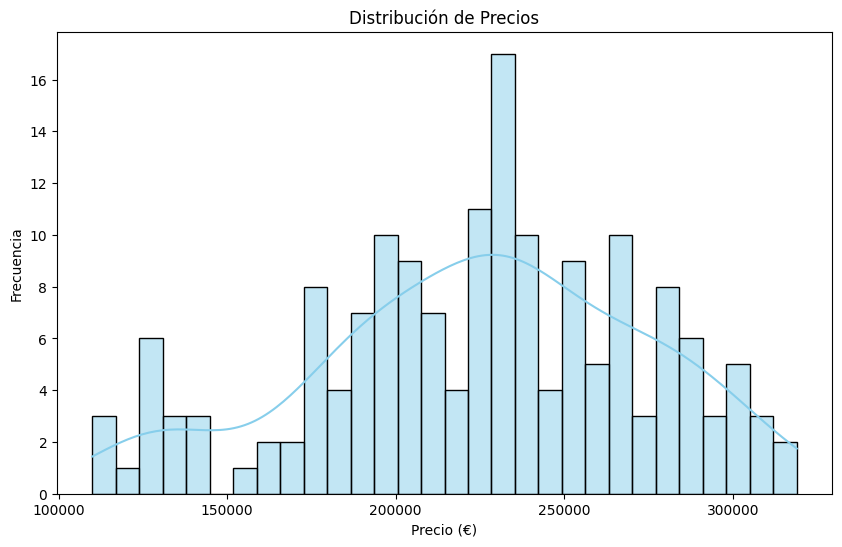

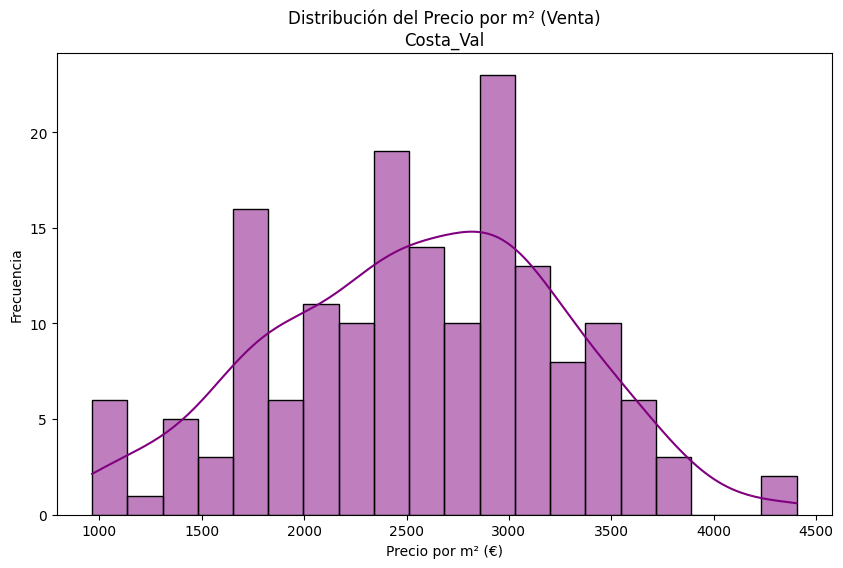

In [4]:
# 4. HISTOGRAMAS DE DISTRIBUCIÓN
# Histograma de Precios
plt.figure(figsize=(10, 6))
sns.histplot(df['Price (€)'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Distribución de Precios')
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia')
plt.savefig(os.path.join(OUTPUT_DIR, 'distribucion_precios.png'), bbox_inches='tight')
plt.show()

# Histograma de Precio Unitario (Precio por Habitación en Rent o por m² en Buy)
plt.figure(figsize=(10, 6))
if is_rent:
    sns.histplot(df['Price/room'].dropna(), kde=True, bins=20, color='lightgreen')
    plt.title(f'Distribución del Precio por Habitación (Alquiler)\n{base_name}')
    plt.xlabel('Precio por Habitación (€/mes)')
    filename = 'rent_price_room_dist.png'
else:
    sns.histplot(df['Price/SqM'].dropna(), kde=True, bins=20, color='purple')
    plt.title(f'Distribución del Precio por m² (Venta)\n{base_name}')
    plt.xlabel('Precio por m² (€)')
    filename = 'buy_price_sqm_dist.png'
plt.ylabel('Frecuencia')
plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches='tight')
plt.show()

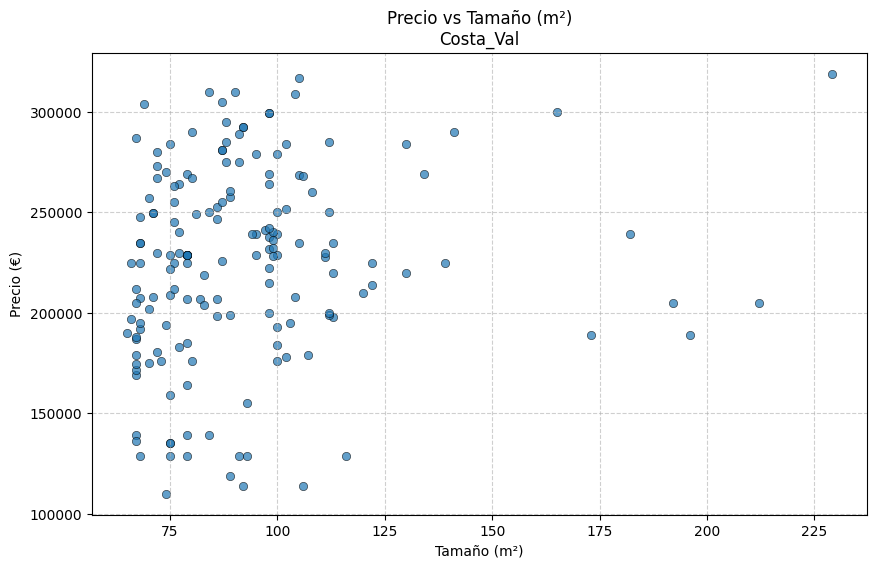

In [5]:
# 5. RELACIÓN PRECIO VS TAMAÑO (SCATTER PLOT)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area (m²)', y='Price (€)', alpha=0.7, edgecolor='k')
plt.title(f'Precio vs Tamaño (m²)\n{base_name}')
plt.xlabel('Tamaño (m²)')
plt.ylabel('Precio (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join(OUTPUT_DIR, 'precio_vs_tamano.png'), bbox_inches='tight')
plt.show()

In [ ]:
""" 
# 6. ANÁLISIS POR UBICACIÓN (BOXPLOTS POR ZONAS)
# Obtener todas las ubicaciones únicas ordenadas por cantidad de propiedades
locations = df['Location'].value_counts().index.tolist()
locs_per_plot = 10

# Dividir las ubicaciones en grupos legibles
for i in range(0, len(locations), locs_per_plot):
    group_locs = locations[i:i+locs_per_plot]
    df_group = df[df['Location'].isin(group_locs)]
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_group, x='Location', y='Price (€)')
    plt.title(f'Dispersión de Precios por Ubicación - Grupo {i//locs_per_plot + 1}')
    plt.xticks(rotation=45, ha='right')
    
    # Guardar y mostrar cada grupo
    filename = f'boxplot_ubicaciones_grupo_{i//locs_per_plot + 1}.png'
    plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches='tight')
    plt.show()
    """

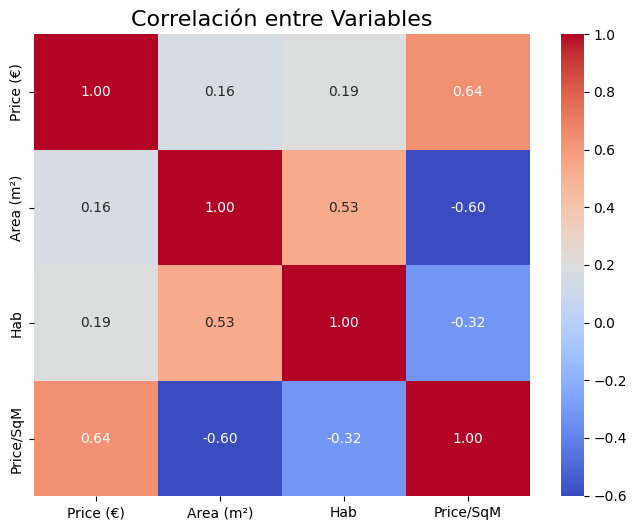

In [7]:

"""
# 8. CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
cols = [c for c in ['Price (€)', 'Area (m²)', 'Hab', 'Price/room' if is_rent else 'Price/SqM'] if c in df.columns]
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre Variables', fontsize=16)
plt.savefig(os.path.join(OUTPUT_DIR, 'correlacion.png'), bbox_inches='tight')
plt.show()
"""


## Filtrado de Inmuebles

Definición de funciones de filtrado personalizadas según las reglas del script original (asumiendo columnas completas).

In [8]:
# 9. FUNCIONES DE FILTRADO DE PROPIEDADES (USO PERSONAL)
def filter_rent_rows(df, mx_pr_1h=1200, mx_pr_room=800, min_area_1h=60, min_area_2h=75, min_area_3h=100, include=None, exclude=None):
    """
    Filtra opciones de alquiler con tamaños mínimos aceptables según cantidad de habs.
    """
    c1 = (df['Hab'] == 1) & (df['Price (€)'] <= mx_pr_1h) & (df['Area (m²)'] >= min_area_1h)
    c2 = (df['Hab'] == 2) & (df['Price/room'] <= mx_pr_room) & (df['Area (m²)'] >= min_area_2h)
    c3 = (df['Hab'] >= 3) & (df['Price/room'] <= mx_pr_room) & (df['Area (m²)'] >= min_area_3h)
    res = df[c1 | c2 | c3]
    if exclude: res = res[~res['Location'].isin(exclude)]
    if include: res = res[res['Location'].isin(include)]
    return res.drop_duplicates().reset_index(drop=True)

def filter_buy_rows(df, min_h=2, min_price_sqm=1500, max_price_sqm=3000, min_area_any=60, min_area_large=100, min_hab_large=3, max_size=200, exclude=None):
    """
    Filtra opciones de compra acotando por precio/m2, descartando pisos muy grandes o muy chicos.
    Asegura que si un piso tiene muchas habitaciones, tenga el tamaño mínimo adecuado para no estar apretados.
    """
    cond = (df['Price/SqM'].between(min_price_sqm, max_price_sqm)) & (df['Area (m²)'].between(min_area_any, max_size)) & (df['Hab'] >= min_h)
    # Si tiene min_hab_large habitaciones o más, el área DEBE ser mayor o igual a min_area_large
    cond &= (df['Hab'] < min_hab_large) | (df['Area (m²)'] >= min_area_large)
    res = df[cond]
    if exclude: res = res[~res['Location'].isin(exclude)]
    return res.drop_duplicates().reset_index(drop=True)

In [9]:
# 10. EJECUTAR FILTRADO DE LA BÚSQUEDA (ALQUILER O COMPRA PERSONAL)
if is_rent:
    exclude_locations = []#['Terrassa', 'Mataró', 'Sabadell', 'Martorell', 'Sant Vicenç de Montalt', 'Cabrera de Mar']
    df_filtrado = filter_rent_rows(df, mx_pr_1h=1000, mx_pr_room=600, min_area_1h=60, min_area_2h=75, min_area_3h=95, exclude=exclude_locations).sort_values(['Hab', 'Area (m²)', 'Price (€)'])
    print(f"--- PROPIEDADES ENCONTRADAS PARA ALQUILER PERSONAL ---\nTotal aptas: {len(df_filtrado)}")
    display(df_filtrado)
else:
    df_filtrado = filter_buy_rows(df, min_h=2, min_price_sqm=1500, max_price_sqm=2900, min_area_any=65, min_area_large=90, min_hab_large=3, max_size=80).sort_values('Price/SqM')
    print(f"--- PROPIEDADES ENCONTRADAS PARA COMPRA PERSONAL ---\nTotal aptas: {len(df_filtrado)}")
    display(df_filtrado)

--- PROPIEDADES ENCONTRADAS PARA COMPRA PERSONAL ---
Total aptas: 26


,Location,Link,Price (€),Area (m²),Hab,Price/SqM
2,"Zona Llombai, Burriana",https://www.idealista.com/obra-nueva/110286753/inmueble/110289790/,129000,75.0,2.0,1720
3,"Zona Llombai, Burriana",https://www.idealista.com/obra-nueva/110286753/inmueble/110289783/,135000,75.0,2.0,1800
4,"Zona Llombai, Burriana",https://www.idealista.com/obra-nueva/110286753/inmueble/110289785/,135000,75.0,2.0,1800
0,"Zona Piscinas, Burriana",https://www.idealista.com/obra-nueva/109709853/inmueble/110196245/,129000,68.0,2.0,1897
5,"Zona Llombai, Burriana",https://www.idealista.com/obra-nueva/110286753/inmueble/110289784/,139000,67.0,2.0,2075
13,"Benipeixcar - El Raval, Gandia",https://www.idealista.com/obra-nueva/110755340/inmueble/111201276/,164000,79.0,2.0,2076
12,"Benipeixcar - El Raval, Gandia",https://www.idealista.com/obra-nueva/110755340/inmueble/110783018/,159000,75.0,2.0,2120
18,"Moncófar playa, Moncofa",https://www.idealista.com/obra-nueva/111156959/inmueble/111158533/,176000,80.0,2.0,2200
19,"Zona Piscinas, Burriana",https://www.idealista.com/obra-nueva/111608355/inmueble/111644902/,185000,79.0,2.0,2342
16,"Avda de Abril - 9 de Octubre, Puerto de Sagunto",https://www.idealista.com/obra-nueva/110292198/inmueble/111762497/,183226,77.0,2.0,2380


In [ ]:


# Obtenemos todos los links validos (sin nulos)
links = df_filtrado['Link'].dropna().tolist()
print(f"Se van a abrir {len(links)} links en tu navegador...")

for link in links:
    webbrowser.open(link)
    time.sleep(0.5)  # Pausa de medio segundo entre cada pestaña


Se van a abrir 26 links en tu navegador...
